In [1]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import scipy.stats as stats

## Executive Summary

This analysis examines whether housing unaffordability predicts adverse health 
outcomes across California's 58 counties from 2016 to 2024. Using the Median 
Multiple — median home price divided by median household income — as a measure 
of housing affordability, three population health outcomes are modeled: premature 
death rate, poor mental health days, and preventable hospitalization rate.

Two-way fixed effects (TWFE) regression isolates within-county changes over time, 
controlling for stable county characteristics and California-wide temporal trends. 
Lagged specifications test whether affordability predicts health outcomes across 
one to seven year time horizons.

No reliable relationship between housing affordability and the three health outcomes 
is detected in either contemporaneous or lagged models. One statistically significant 
finding — a negative association between Median Multiple and poor mental health days 
— runs counter to the hypothesized direction and is attributable to chance given 
the number of model specifications tested. The absence of a detectable signal is 
interpreted in the context of residential sorting, credit buffering, and the 
temporal limitations of a nine-year observation window relative to the decades-long 
pathways through which housing stress is hypothesized to affect health.

In [2]:
# Load full panel data
file_path = '../data/processed/full_panel.csv'
full_panel_df = pd.read_csv(file_path, header=0)
full_panel_df.head()

,fips,county,premature_death_rate,poor_mental_health_days,preventable_hosp_rate,children_in_poverty_pct,low_birthweight_pct,year,median_home_value,median_household_income,income_source,median_multiple
0,6001,Alameda,4885.7,3.3,3786.0,14.3,7.243144,2016,727366.137571,89979.0,1yr,8.083732
1,6003,Alpine,NaN,4.1,NaN,28.2,NaN,2016,354178.372722,62375.0,5yr,5.678210
2,6005,Amador,5775.7,3.5,3607.0,18.6,6.313646,2016,283142.893730,57032.0,5yr,4.964632
3,6007,Butte,7436.8,4.2,4629.0,24.3,5.810629,2016,259383.088246,45177.0,1yr,5.741485
4,6009,Calaveras,7536.8,3.5,3548.0,20.6,4.827586,2016,274860.946378,53502.0,5yr,5.137396


In [3]:
full_panel_df.describe()

,fips,premature_death_rate,poor_mental_health_days,preventable_hosp_rate,children_in_poverty_pct,low_birthweight_pct,year,median_home_value,median_household_income,median_multiple
count,522.000000,504.000000,522.000000,517.000000,522.000000,513.000000,522.000000,5.220000e+02,482.000000,482.000000
mean,6058.000000,6695.972995,4.240015,3205.746615,18.776437,6.586286,2020.000000,5.132549e+05,74273.831950,6.452715
std,33.513454,2064.490679,0.645316,1084.203936,7.299489,0.793038,2.584466,3.042935e+05,24303.488881,1.871963
min,6001.000000,3133.003305,2.879073,921.000000,5.500000,4.483612,2016.000000,1.114962e+05,35270.000000,2.619685
25%,6029.000000,5002.459693,3.760310,2429.000000,13.000000,6.031819,2018.000000,2.957358e+05,56484.000000,5.117031
50%,6058.000000,6594.034256,4.116067,3078.000000,18.200000,6.451613,2020.000000,4.143988e+05,67419.500000,5.967431
75%,6087.000000,7892.101875,4.682376,3808.000000,23.775000,6.976612,2022.000000,6.290468e+05,87700.250000,7.713978
max,6115.000000,15509.465353,6.238212,6648.000000,38.000000,10.055866,2024.000000,1.642988e+06,168154.000000,11.716973


## Descriptive Statistics — Key Observations

Descriptive statistics of the dataset reveal the following notable patterns:

- **Median Multiple:** Mean of 6.45 and median of 5.97 indicate slight right 
  skew driven by extreme high values. The max of 11.72 is nearly four times 
  Demographia's affordability threshold of 3.0. The full range (2.62–11.72) 
  provides meaningful variation for regression analysis despite California's 
  overall bias toward unaffordability. Note: count is 482 rather than 522 due 
  to missing 2020 income data (COVID-19 ACS suspension).

- **Premature Death Rate (per 100,000):** Mean of 6,696 and median of 6,594 
  suggest a relatively symmetrical distribution. The maximum value of 15,509 
  warrants investigation. A nearly five-fold difference between minimum and 
  maximum values indicates substantial county-level variation. Count is 504 
  due to data suppression in Alpine and Sierra counties.

- **Preventable Hospitalization Rate:** A 7.2-fold difference between minimum 
  (921) and maximum (6,648) indicates significant variation. The maximum value 
  warrants investigation.

- **Children in Poverty:** A 6.9-fold difference between minimum and maximum 
  values reflects substantial economic disparity across California counties.






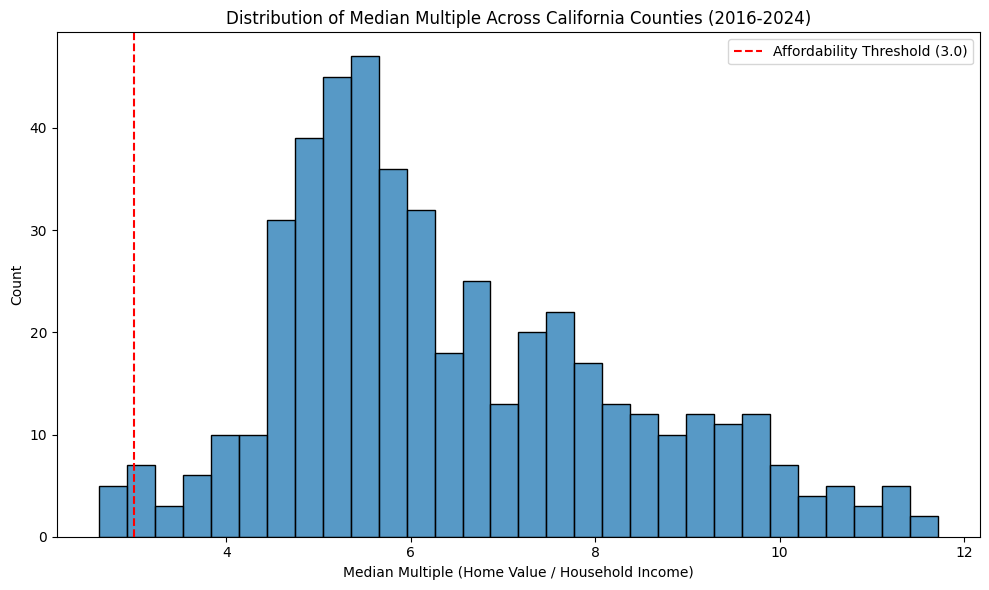

In [4]:
# Inspect distribution of Median Multiple Across CA

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=full_panel_df, x='median_multiple', bins=30, ax=ax)
ax.set_title('Distribution of Median Multiple Across California Counties (2016-2024)')
ax.set_xlabel('Median Multiple (Home Value / Household Income)')
ax.set_ylabel('Count')
ax.axvline(x=3.0, color='red', linestyle='--', label='Affordability Threshold (3.0)')
ax.legend()
plt.tight_layout()
plt.show()



In [5]:
affordable = full_panel_df['median_multiple'] < 3.0
affordable_count = affordable.sum()
percent_affordable = affordable_count / full_panel_df['median_multiple'].notna().sum() * 100
print(f'Affordable county-years (MM < 3.0): {affordable_count}')
print(f'Percent affordable: {percent_affordable:.1f}%')



Affordable county-years (MM < 3.0): 6
Percent affordable: 1.2%


In [6]:
full_panel_df['median_multiple'].round(1).mode()

0    5.1
Name: median_multiple, dtype: float64

## Distribution of Median Multiple

Only 6 of 482 county-years (1.2%) fall below Demographia's affordability 
threshold of 3.0, confirming that housing unaffordability is effectively 
universal across California counties during the 2016–2024 analysis period.

The mode of the Median Multiple (rounded to one decimal place) is 5.1 — 
slightly below the median of 5.97 and meaningfully below the mean of 6.45. 
This suggests that while most counties cluster in the seriously unaffordable 
range (4.1–5.0), a subset of high-cost counties — likely those proximal to 
Los Angeles and the Bay Area — drive the mean upward. The distribution shows 
a pronounced right tail extending beyond 10.0, indicating that extreme 
unaffordability is concentrated in a smaller number of high-demand urban counties.

### Methodological Limitations

The clustering of values between approximately 4.7 and 6.3 creates **range 
restriction** — limited variation in the predictor reduces statistical power 
and may obscure non-linear or compounding effects.

Additionally, severely unaffordable counties tend to be high-wealth economic 
hubs, introducing confounding. **Residential sorting** — where economically 
stressed residents migrate from expensive urban counties to more affordable 
rural ones — may distribute the health consequences of housing unaffordability 
geographically, decoupling the effect from its origin. This suggests our 
analysis may underestimate the true health impact of housing unaffordability.

## Distribution of Health Outcome Variables

The three primary outcome variables are examined below for distributional 
characteristics prior to regression analysis. Understanding the shape and 
spread of each outcome informs model specification and helps identify 
potential outliers that may influence results.

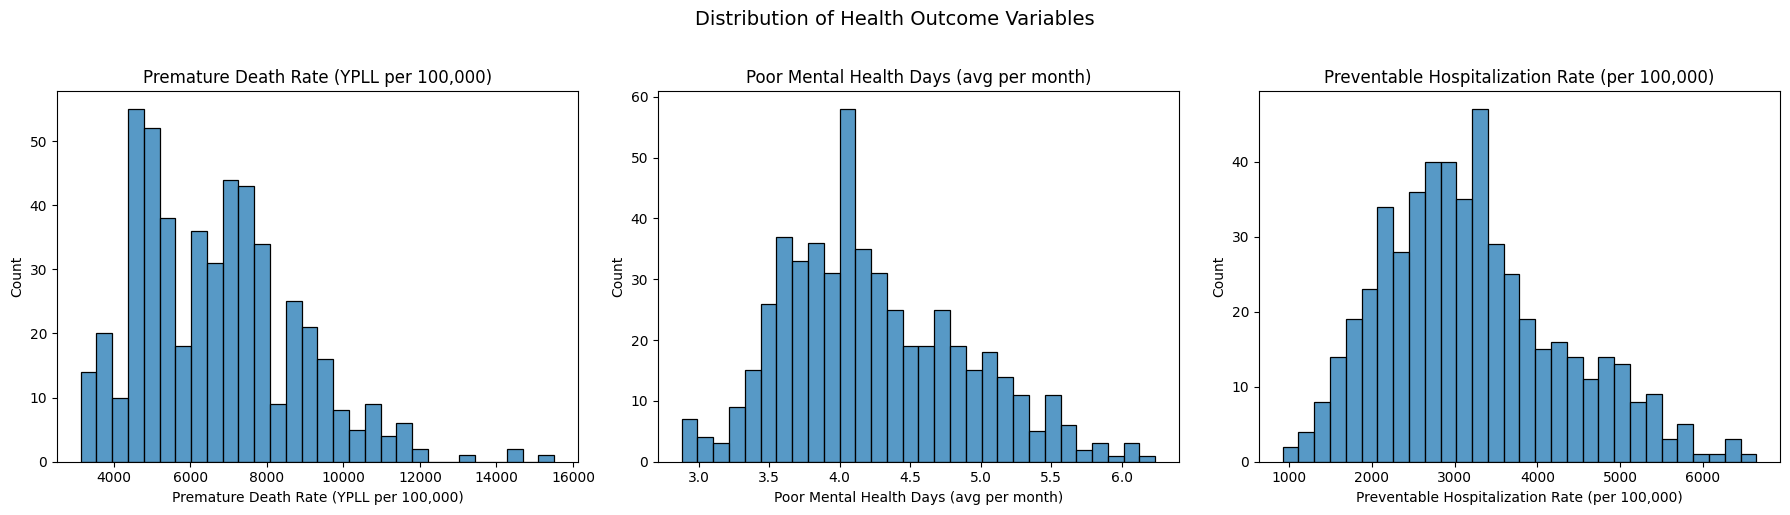

In [7]:
outcome_vars = [
    ('premature_death_rate', 'Premature Death Rate (YPLL per 100,000)'),
    ('poor_mental_health_days', 'Poor Mental Health Days (avg per month)'),
    ('preventable_hosp_rate', 'Preventable Hospitalization Rate (per 100,000)')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (var, label) in enumerate(outcome_vars):
    sns.histplot(data=full_panel_df, x=var, bins=30, ax=axes[i])
    axes[i].set_title(label)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Health Outcome Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Observations — Health Outcome Variable Distributions

**Premature Death Rate** exhibits a trimodal distribution with peaks at 
approximately 5,000, 7,300, and 9,100 YPLL per 100,000. This pattern suggests 
three distinct county clusters with different underlying health profiles — 
likely reflecting California's geographic and economic stratification. 
Further investigation of these modes is warranted.

**Poor Mental Health Days** shows a pronounced right skew with a sharp peak 
at approximately 4.1 days per month, indicating that most counties cluster 
around a relatively low baseline while a subset of county-years report 
significantly higher mental health burden.

**Preventable Hospitalization Rate** approximates a normal distribution with 
a right tail, centered between 2,500 and 3,200 per 100,000.

All three outcome variables exhibit right skew, suggesting that poor health 
outcomes in a subset of county-years are pulling the mean rightward. This 
pattern identifies potential targets for intervention and motivates outlier 
investigation in subsequent analysis.

### Premature Death Rate Outlier Investigation

In [8]:
full_panel_df.nlargest(15, 'premature_death_rate')[['county', 'year', 'premature_death_rate']]

,county,year,premature_death_rate
516,Trinity,2024,15509.465353
400,Trinity,2022,14307.233951
458,Trinity,2023,14307.233951
342,Trinity,2021,13183.426220
510,Siskiyou,2024,11921.754914
480,Lake,2024,11808.001434
132,Lake,2018,11667.015400
306,Lake,2021,11656.951360
190,Lake,2019,11578.018825
364,Lake,2022,11558.925676


In [9]:
full_panel_df.nsmallest(15, 'premature_death_rate')[['county', 'year', 'premature_death_rate']]

,county,year,premature_death_rate
194,Marin,2019,3133.003305
252,Marin,2020,3206.631803
310,Marin,2021,3238.997376
330,San Mateo,2021,3296.851510
373,Mono,2022,3314.891816
431,Mono,2023,3314.891816
272,San Mateo,2020,3367.811038
257,Mono,2020,3369.601629
136,Marin,2018,3447.674481
214,San Mateo,2019,3469.797831


### Premature Death Rate — Outlier Investigation

The top 15 county-years by premature death rate reveal a striking geographic 
pattern. Despite a nearly five-fold difference between minimum and maximum 
values, the extreme high end is dominated by a small cluster of rural northern 
California counties:

- **Trinity County** appears 5 times in the top 15, including the maximum 
  value of 15,509 per 100,000 in 2024 — nearly 2.5x the dataset mean
- **Lake County** appears 7 times, accounting for 46.7% of the top 15 observations
- **Siskiyou** and **Modoc** counties appear less frequently but share the same 
  underlying structural characteristics — rural, economically depressed, 
  limited healthcare access

Notably, these counties have among the *lowest* Median Multiple values in the 
dataset, reinforcing the confounding relationship identified in the correlation 
matrix. The counties with the worst health outcomes are paradoxically among 
the most "affordable" — reflecting economic depression rather than housing 
accessibility. This pattern underscores the importance of fixed effects 
regression to isolate within-county changes over time from these structural 
between-county differences.

### Lowest Values

The 15 county-years with the lowest premature death rates reveal an equally 
clear geographic and economic pattern, in stark contrast to the highest values.

- **Marin County** holds the three lowest values in the dataset and appears 
  4 times in the bottom 15 — the wealthiest county in California by median 
  household income
- **San Mateo County** appears 7 times, accounting for 46.7% of the bottom 15
- **Santa Clara County** also appears, rounding out the Bay Area cluster

Marin, San Mateo, and Santa Clara are wealthy communities proximal to major 
economic hubs with excellent healthcare access, food security infrastructure, 
and active lifestyle amenities — all well-established social determinants of 
health.

**Mono County** is a notable anomaly, appearing 3 times despite being a small 
rural county with characteristics more similar to Trinity and Lake than to the 
Bay Area suburbs. Mono's low premature death rate warrants further investigation 
— possible explanations include its small population (suppression effects), 
a relatively young and active outdoor recreation demographic, or data 
reliability issues given its size.

### Poor Mental Health Days - Outlier Investigation

In [10]:
full_panel_df.nlargest(15, 'poor_mental_health_days')[['county', 'year', 'poor_mental_health_days']]

,county,year,poor_mental_health_days
475,Humboldt,2024,6.238212
516,Trinity,2024,6.124921
480,Lake,2024,6.078909
510,Siskiyou,2024,6.029029
515,Tehama,2024,5.990070
488,Modoc,2024,5.825901
468,Calaveras,2024,5.807254
471,Del Norte,2024,5.799221
467,Butte,2024,5.757498
486,Mendocino,2024,5.683166


In [11]:

full_panel_df.nsmallest(15, 'poor_mental_health_days')[['county', 'year', 'poor_mental_health_days']]

,county,year,poor_mental_health_days
274,Santa Clara,2020,2.879073
42,Santa Clara,2016,2.900000
158,Santa Clara,2018,2.900524
216,Santa Clara,2019,2.900524
156,San Mateo,2018,2.948116
214,San Mateo,2019,2.948116
98,San Mateo,2017,2.989343
40,San Mateo,2016,3.000000
100,Santa Clara,2017,3.029473
272,San Mateo,2020,3.078771


### Poor Mental Health Days — Outlier Investigation

The top 15 county-years by poor mental health days reveal a striking pattern: 
every instance is from 2024, the final year of the dataset. This concentration 
suggests a worsening trend in rural mental health during the most recent 
observation period, potentially reflecting compounding post-COVID economic 
and social pressures in already vulnerable communities. All 15 counties are 
rural and economically depressed — consistent with the patterns observed in 
premature death outliers.

The bottom 15 instances are dramatically concentrated in the Bay Area — 
Santa Clara, San Mateo, San Francisco, Alameda, and Marin counties — among 
the wealthiest in California. The contrast between these two lists strongly 
suggests that income and wealth distribution play a significant role in 
shaping county-level mental health outcomes.

### Preventable Hospitalization Rate -  Outlier Investigation

In [12]:
full_panel_df.nlargest(15, 'preventable_hosp_rate')[['county', 'year', 'preventable_hosp_rate']]

,county,year,preventable_hosp_rate
133,Lassen,2018,6648.0
57,Yuba,2016,6398.0
75,Lassen,2017,6356.0
15,Kings,2016,6309.0
173,Yuba,2018,6130.0
52,Trinity,2016,5923.0
49,Stanislaus,2016,5881.0
14,Kern,2016,5870.0
7,Del Norte,2016,5867.0
110,Trinity,2017,5817.0


In [13]:
full_panel_df.nsmallest(15, 'preventable_hosp_rate')[['county', 'year', 'premature_death_rate']]

,county,year,premature_death_rate
465,Alpine,2024,NaN
477,Inyo,2024,10103.515076
484,Marin,2024,3856.255720
426,Marin,2023,3554.693211
407,Alpine,2023,NaN
510,Siskiyou,2024,11921.754914
503,San Luis Obispo,2024,5707.287157
489,Mono,2024,4788.617268
447,Santa Barbara,2023,5333.969437
505,Santa Barbara,2024,5775.069639


### Preventable Hospitalization Rate — Outlier Investigation

The top 15 county-years by preventable hospitalization rate show a more 
distributed pattern than premature death, though rural northern and Central 
Valley counties again dominate. Lassen and Yuba each appear 3 times as the 
highest frequency counties, sharing structural characteristics with the 
premature death outliers — rural, low-income, limited healthcare access.

Notably, only Trinity County appears in both the top 15 premature death and 
top 15 preventable hospitalization lists. This limited overlap suggests that 
the drivers of premature death and preventable hospitalizations are not 
identical, and that these outcomes may respond differently to housing 
unaffordability and other social determinants.

The year distribution is also notable — 13 of the top 15 values come from 
2016–2018, reflecting the higher baseline rates in earlier years. The mean 
preventable hospitalization rate declined from 4,097 in 2016 to 2,097 in 2024, 
a 50% reduction that likely reflects broader improvements in ambulatory care 
access across California during this period.

## Distribution of Health Contextual Variables

The two contextual variables are examined below for distributional 
characteristics prior to regression analysis. Understanding the shape and 
spread of each informs model specification and helps identify 
potential outliers that may influence results.

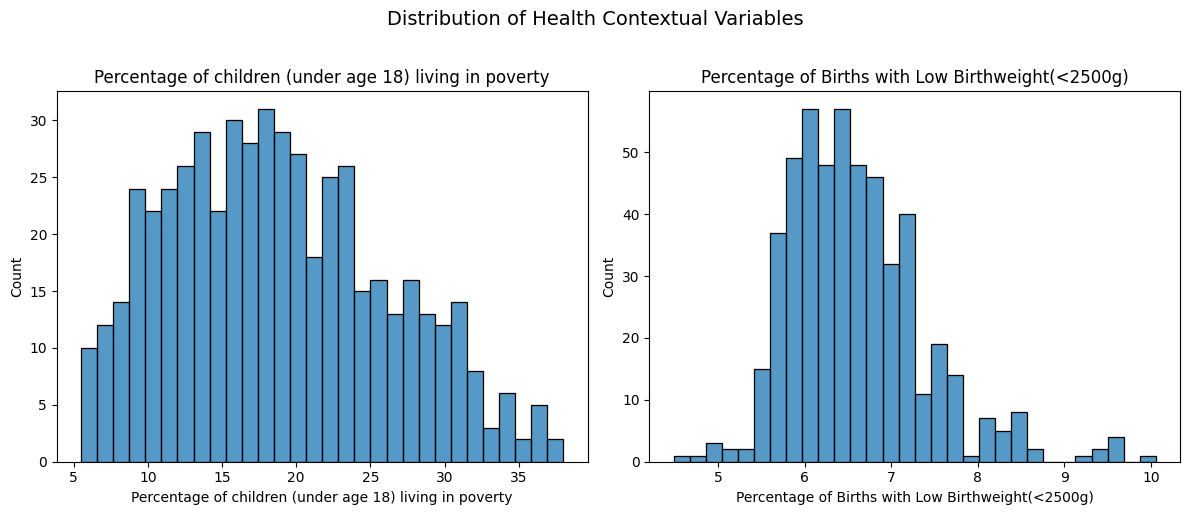

In [14]:
contextual_vars = [
    ('children_in_poverty_pct', 'Percentage of children (under age 18) living in poverty'),
    ('low_birthweight_pct', 'Percentage of Births with Low Birthweight(<2500g)'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (var, label) in enumerate(contextual_vars):
    sns.histplot(data=full_panel_df, x=var, bins=30, ax=axes[i])
    axes[i].set_title(label)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Health Contextual Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Distribution of Children in Poverty Percentage

The childhood poverty distribution is closer to normal than the other observed 
variables, centered at approximately 18.5% with a mean of 18.78 and median of 
18.2. A pronounced floor at approximately 5.5% suggests that even the wealthiest 
California counties maintain a baseline childhood poverty rate due to structural 
factors.

The 6.9-fold difference between minimum and maximum values reflects substantial 
geographic variation in child welfare outcomes across California counties. This 
range has meaningful lifetime health implications — there is a significant body 
of research connecting childhood poverty to adverse childhood experiences (ACEs), 
which in turn are strongly associated with poor lifetime health outcomes across 
multiple domains including cardiovascular disease, mental health, and substance use.

### Distribution of Low Birthweight Percentage

The low birthweight distribution centers around 6.5% with a mean of 6.59 and 
median of 6.45. Notably, the range is considerably tighter than other outcome 
variables — the minimum (4.48%) is only 2.24 times smaller than the maximum 
(10.06%), suggesting biological constraints limit variation in this outcome. 
This raises the possibility that low birthweight may be less responsive to 
social determinants than the other outcome variables in this analysis.

## Childhood Poverty Outlier Investigation

In [15]:
full_panel_df.nsmallest(15, 'children_in_poverty_pct')[['county', 'year', 'children_in_poverty_pct']]

,county,year,children_in_poverty_pct
332,Santa Clara,2021,5.5
494,Placer,2024,5.5
388,San Mateo,2022,5.6
368,Marin,2022,5.8
378,Placer,2022,6.2
330,San Mateo,2021,6.3
252,Marin,2020,6.4
390,Santa Clara,2022,6.5
446,San Mateo,2023,6.5
472,El Dorado,2024,6.5


In [16]:
full_panel_df.nlargest(15, 'children_in_poverty_pct')[['county', 'year', 'children_in_poverty_pct']]

,county,year,children_in_poverty_pct
9,Fresno,2016,38.0
125,Fresno,2018,37.0
53,Tulare,2016,36.7
67,Fresno,2017,36.3
111,Tulare,2017,36.3
23,Merced,2016,35.9
81,Merced,2017,35.9
59,Alpine,2017,35.7
175,Alpine,2019,35.3
233,Alpine,2020,34.7


## Low Birthweight Outlier Investigation

In [17]:
full_panel_df.nsmallest(15, 'low_birthweight_pct')[['county', 'year', 'low_birthweight_pct']]

,county,year,low_birthweight_pct
54,Tuolumne,2016,4.483612
4,Calaveras,2016,4.827586
226,Trinity,2019,4.881101
7,Del Norte,2016,4.892704
112,Tuolumne,2017,5.009334
120,Calaveras,2018,5.050916
65,Del Norte,2017,5.137135
62,Calaveras,2017,5.300207
123,Del Norte,2018,5.309735
186,Imperial,2019,5.427332


In [18]:
full_panel_df.nlargest(15, 'low_birthweight_pct')[['county', 'year', 'low_birthweight_pct']]

,county,year,low_birthweight_pct
509,Sierra,2024,10.055866
393,Sierra,2022,9.574468
451,Sierra,2023,9.574468
379,Plumas,2022,9.498681
437,Plumas,2023,9.498681
263,Plumas,2020,9.335727
321,Plumas,2021,9.333333
205,Plumas,2019,9.245961
495,Plumas,2024,8.730159
219,Sierra,2019,8.670520


Outlier investigation reveals a striking pattern. The top 15 highest low 
birthweight rates are dominated by three rural northern California counties:
- **Plumas County** appears 6 times (40% of the list)
- **Sierra County** appears 5 times (33.3% of the list)  
- **Siskiyou County** appears 3 times

The geographic concentration and temporal consistency of these counties 
suggests a potential environmental or structural determinant rather than 
random variation. Further investigation is warranted.

The bottom 15 values are notably absent of high-wealth Bay Area counties — 
unlike the premature death low outliers — further suggesting that the drivers 
of low birthweight may differ from those of other health outcomes in this dataset.

## Correlation Matrix of All Variables

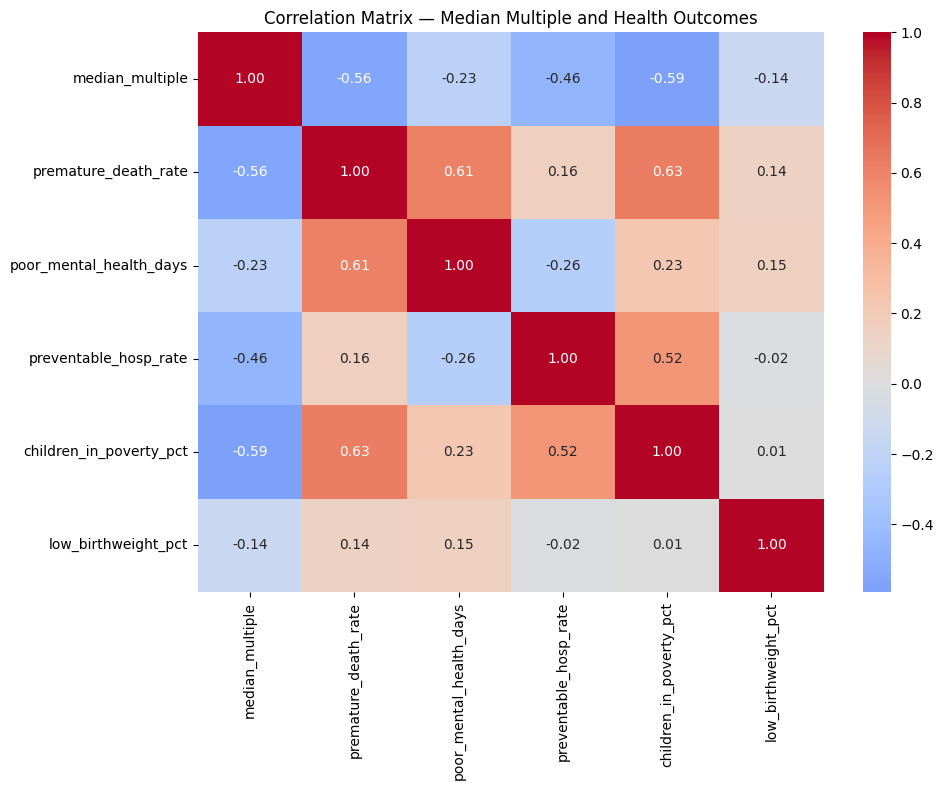

In [19]:
# Correlation matrix — Median Multiple vs outcome variables
corr_cols = ['median_multiple', 'premature_death_rate', 'poor_mental_health_days', 
             'preventable_hosp_rate', 'children_in_poverty_pct', 'low_birthweight_pct']

corr_matrix = full_panel_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax)
ax.set_title('Correlation Matrix — Median Multiple and Health Outcomes')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



### Correlation Matrix — Observations

The most striking pattern is the negative correlation between the Median 
Multiple and all outcome and contextual variables. This counterintuitive finding 
suggests that wealth concentration in high-cost counties acts as a confounding 
variable, obscuring the relationship between housing unaffordability and adverse 
health outcomes. Additionally, residential sorting — where higher-income 
households self-select into high-cost counties based on earning potential and 
opportunity — further decouples housing cost from health burden at the 
county level.

The strongest negative correlations with Median Multiple are:
- **Children in Poverty** (r = -0.59)
- **Premature Death Rate** (r = -0.56)

The presence of childhood poverty as the most negatively correlated variable 
with Median Multiple is striking — Counties with **lower housing affordability** 
(higher Median Multiple) have *lower* child poverty rates, reflecting wealth concentration rather than 
a protective effect of unaffordability. This confounding relationship 
underscores the necessity of fixed effects regression to isolate within-county 
changes over time.

Among outcome variables, the strongest positive correlations are:
- **Premature Death Rate and Children in Poverty** (r = 0.63) — suggesting 
  co-occurring extreme deprivation at the county level
- **Premature Death Rate and Poor Mental Health Days** (r = 0.61) — indicating 
  a cluster of compounding negative outcomes associated with poverty
- **Preventable Hospitalization Rate and Children in Poverty** (r = 0.52) — 
  a potentially important finding suggesting that childhood poverty may be 
  associated with reduced intention-based parental behavior, parental executive 
  function challenges, and addiction-related presentations, all of which 
  warrant further investigation

### Mediation Analysis — Scope Note

Children in Poverty and Low Birthweight were originally identified during 
data selection (Notebook 01) as potential mediators for a planned mediation 
analysis, under the hypothesis that housing unaffordability drives adverse 
health outcomes partly through its effect on childhood poverty and birth 
outcomes.

The correlation matrix above shows Median Multiple correlated negatively 
with both variables (Children in Poverty: r = -0.59; Low Birthweight: 
r = -0.14) — the opposite direction predicted by that hypothesis. Counties 
with less affordable housing show *lower*, not higher, rates of both. As 
discussed above, this pattern is most consistent with the same between-county 
wealth-concentration confound that motivates the fixed-effects approach used 
for the outcome variables: expensive counties are disproportionately wealthy 
counties, and wealth concentration plausibly suppresses both variables 
independent of any causal link to housing cost itself.

Mediation analysis was not carried out on either candidate variable. Low 
Birthweight was ruled out first: its correlations with every other variable 
in the dataset ranged from -0.14 to 0.15, indicating essentially no signal 
to work with. Children in Poverty is harder to dismiss on the same grounds, 
since it holds some of the strongest correlations in the dataset, including 
r = 0.63 with Premature Death Rate and r = 0.52 with Preventable 
Hospitalization Rate. However, the originally scoped three-variable chain — 
Median Multiple leading to Children in Poverty leading to a health outcome — 
does not hold, because the first leg runs in the wrong direction: Median 
Multiple and Children in Poverty are correlated at r = -0.59, the opposite of 
what the original hypothesis required. This leaves an unexplored, 
out-of-scope question: whether Children in Poverty functions as a statistical 
predictor, in the regression sense, of Premature Death Rate or Preventable 
Hospitalization Rate on its own. That relationship was not investigated 
further here.

## Model Selection

The correlation matrix reveals a confounding relationship that makes cross-sectional 
analysis unreliable: expensive counties tend to be wealthy counties, and wealthy 
counties tend to have better health outcomes. A naive OLS regression would likely 
show that lower home affordability produces *better* health — the opposite of the 
hypothesized direction — simply because of this between-county wealth effect.

Two-way fixed effects (TWFE) regression addresses this by restricting identification 
to within-county variation over time. By including county fixed effects (αi) and 
year fixed effects (λt), the model absorbs all time-stable county characteristics 
— relatively static wealth dynamics, geography, healthcare infrastructure — as well as 
California-wide shocks common to all counties in a given year such as the 
COVID-19 pandemic. The coefficient on Median Multiple therefore reflects whether 
a county's health outcomes changed as its housing affordability changed, holding 
its baseline characteristics constant.

Three outcomes are modeled separately: Premature Death Rate, Poor Mental Health 
Days, and Preventable Hospitalization Rate. Clustered standard errors at the 
county level account for within-county correlation of residuals across years.

In [20]:
# Note: clustered SE warnings ("covariance of constraints does not have full rank")
# occur because the number of county fixed effect dummies exceeds the effective
# number of clusters after listwise deletion on missing income data. This limits
# the precision of the SE estimates and is acknowledged in the Limitations section.

df_premature = full_panel_df.dropna(subset=['premature_death_rate', 'median_multiple']).reset_index(drop=True)

model_premature = smf.ols(
    'premature_death_rate ~ median_multiple + C(fips) + C(year)',
    data=df_premature
).fit(cov_type='cluster', cov_kwds={'groups': df_premature['fips']})

print(model_premature.summary())

                             OLS Regression Results                             
Dep. Variable:     premature_death_rate   R-squared:                       0.958
Model:                              OLS   Adj. R-squared:                  0.952
Method:                   Least Squares   F-statistic:                     357.2
Date:                  Sun, 30 Aug 2026   Prob (F-statistic):           1.88e-45
Time:                          14:53:20   Log-Likelihood:                -3465.1
No. Observations:                   464   AIC:                             7060.
Df Residuals:                       399   BIC:                             7329.
Df Model:                            64                                         
Covariance Type:                cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        5514.

/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 64, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [21]:
df_mental_health = full_panel_df.dropna(subset=['poor_mental_health_days', 'median_multiple']).reset_index(drop=True)

model_mental_health = smf.ols(
    'poor_mental_health_days ~ median_multiple + C(fips) + C(year)',
    data=df_mental_health
).fit(cov_type='cluster', cov_kwds={'groups': df_mental_health['fips']})

print(model_mental_health.summary())

                               OLS Regression Results                              
Dep. Variable:     poor_mental_health_days   R-squared:                       0.959
Model:                                 OLS   Adj. R-squared:                  0.953
Method:                      Least Squares   F-statistic:                     324.2
Date:                     Sun, 30 Aug 2026   Prob (F-statistic):           1.46e-45
Time:                             14:53:20   Log-Likelihood:                 294.38
No. Observations:                      482   AIC:                            -454.8
Df Residuals:                          415   BIC:                            -174.8
Df Model:                               66                                         
Covariance Type:                   cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 66, but rank is 9
  warnings.warn('covariance of constraints does not have full '


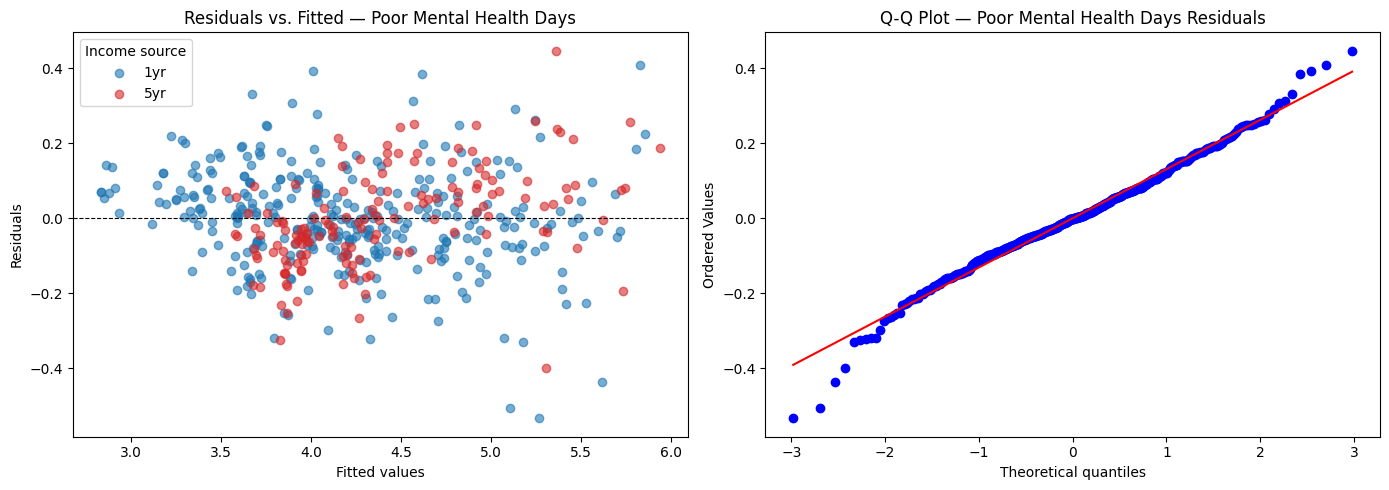

In [22]:
# Attach residuals and fitted values back onto the dataframe used to fit the model
df_mental_health['resid'] = model_mental_health.resid
df_mental_health['fitted'] = model_mental_health.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs. Fitted, colored by income_source
colors = {'1yr': 'tab:blue', '5yr': 'tab:red'}
for source, group in df_mental_health.groupby('income_source'):
    axes[0].scatter(group['fitted'], group['resid'],
                     label=source, alpha=0.6, color=colors[source])
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted — Poor Mental Health Days')
axes[0].legend(title='Income source')

# Q-Q plot of residuals
stats.probplot(df_mental_health['resid'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot — Poor Mental Health Days Residuals')

plt.tight_layout()
plt.show()

In [27]:
grp_1yr = df_mental_health.loc[df_mental_health['income_source'] == '1yr', 'resid']
grp_5yr = df_mental_health.loc[df_mental_health['income_source'] == '5yr', 'resid']

levene_result = stats.levene(grp_1yr, grp_5yr)
ttest_result = stats.ttest_ind(grp_1yr, grp_5yr, equal_var=False)

print("Levene's test (equal variance):", levene_result)
print("Welch's t-test (equal mean):", ttest_result)
print()
print(df_mental_health.groupby('income_source')['resid'].agg(['mean', 'std', 'count']))

Levene's test (equal variance): LeveneResult(statistic=0.10733987649568176, pvalue=0.7433360599142105)
Welch's t-test (equal mean): TtestResult(statistic=0.13297766592315693, pvalue=0.8942994951009121, df=302.3736253236195)

                  mean       std  count
income_source                          
1yr            0.00054  0.132531    329
5yr           -0.00116  0.129717    153


In [30]:
low_fitted = df_mental_health[df_mental_health['fitted'] < 3.6]

pct_positive_low = (low_fitted['resid'] > 0).mean() * 100
pct_positive_overall = (df_mental_health['resid'] > 0).mean() * 100

print("Rows with fitted < 3.6:", len(low_fitted))
print("Percent positive residuals in that region:", round(pct_positive_low, 1))
print("Percent positive residuals overall:", round(pct_positive_overall, 1))

from statsmodels.stats.proportion import proportions_ztest

count_positive = (low_fitted['resid'] > 0).sum()
n_obs = len(low_fitted)
baseline_rate = df_mental_health['resid'].gt(0).mean()

z_stat, p_val = proportions_ztest(count=count_positive, nobs=n_obs, value=baseline_rate)
print("Proportions z-test — p-value:", p_val)

Rows with fitted < 3.6: 60
Percent positive residuals in that region: 76.7
Percent positive residuals overall: 49.4
Proportions z-test — p-value: 5.800933714907279e-07


In [29]:
low_fitted[['county', 'year', 'fitted', 'resid', 'income_source']].sort_values('fitted')

,county,year,fitted,resid,income_source
158,Santa Clara,2018,2.830663,0.069861,1yr
42,Santa Clara,2016,2.830767,0.069233,1yr
216,Santa Clara,2019,2.847407,0.053117,1yr
40,San Mateo,2016,2.858110,0.141890,1yr
156,San Mateo,2018,2.879398,0.068718,1yr
100,Santa Clara,2017,2.891731,0.137743,1yr
98,San Mateo,2017,2.908683,0.080660,1yr
214,San Mateo,2019,2.933175,0.014940,1yr
37,San Francisco,2016,3.113987,-0.013987,1yr
153,San Francisco,2018,3.141175,0.089103,1yr


In [23]:

df_prevent_hosp = full_panel_df.dropna(subset=['preventable_hosp_rate', 'median_multiple']).reset_index(drop=True)

model_preventable_hosp = smf.ols(
    'preventable_hosp_rate ~ median_multiple + C(fips) + C(year)',
    data=df_prevent_hosp
).fit(cov_type='cluster', cov_kwds={'groups': df_prevent_hosp['fips']})

print(model_preventable_hosp.summary())

                              OLS Regression Results                             
Dep. Variable:     preventable_hosp_rate   R-squared:                       0.853
Model:                               OLS   Adj. R-squared:                  0.829
Method:                    Least Squares   F-statistic:                     82.07
Date:                   Sun, 30 Aug 2026   Prob (F-statistic):           2.54e-29
Time:                           14:53:20   Log-Likelihood:                -3558.9
No. Observations:                    477   AIC:                             7252.
Df Residuals:                        410   BIC:                             7531.
Df Model:                             66                                         
Covariance Type:                 cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept   

/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 66, but rank is 9
  warnings.warn('covariance of constraints does not have full '


### TWFE Model Results

Across all three outcomes, the Median Multiple coefficient is small, 
unstable in sign, and statistically indistinguishable from zero in 
two of three models.

**Premature Death Rate** (coef = -148.6, p = 0.264): A one-unit increase 
in Median Multiple — meaning median home price rises by one additional 
year of median income — is associated with approximately 149 fewer 
premature deaths per 100,000 within a county over time, but this 
estimate is imprecise and not statistically significant.

**Poor Mental Health Days** (coef = -0.053, p = 0.034): The only 
statistically significant finding. Higher Median Multiple is associated 
with slightly fewer poor mental health days — a direction opposite to 
the hypothesized relationship. Given that three outcome models are tested 
simultaneously, and this single significant result runs counter to the 
hypothesized direction, it is plausibly noise. The lagged analysis that 
follows will provide a further test of whether this finding replicates 
across varying time horizons.

**Preventable Hospitalization Rate** (coef = 14.5, p = 0.877): No 
meaningful relationship. Notably, the year fixed effects for this 
outcome show a strong and consistent decline across 2017–2024 
(ranging from -377 to -1,995 per 100,000), suggesting a California-wide 
downward trend in preventable hospitalizations independent of housing 
affordability — a finding that warrants separate investigation.

Taken together, these contemporaneous models find no reliable within-county 
relationship between housing affordability and the three health outcomes 
examined. This motivates the lagged specification that follows.

### Limitations — Income Data Source for Rural Counties

Eighteen of the 58 California counties (population under 65,000) are excluded from
the Census Bureau's ACS 1-year income estimates and are substituted with ACS 5-year
estimates in this analysis (flagged via the `income_source` column). These same
counties — including Trinity, Lassen, Plumas, Siskiyou, and Modoc — recur
disproportionately in the outlier investigations above for premature death,
preventable hospitalization, and low birthweight.

The 5-year ACS estimate is not an average of five separate annual estimates; it is
constructed by pooling five years of a given county's raw survey respondents into a
single combined sample, then weighting and estimating once from that pool
(Raglin, 2022). This is done because an individual year's sample in a small
rural county is too thin to produce a statistically reliable annual estimate. A
practical consequence follows directly from the construction: the pooled mean
should be a reasonably reliable estimate of income level for that county, but
year-to-year variation within the five-year window is not captured — it is
absorbed into a single period estimate by design, not smoothed after the fact.

This matters for a two-way fixed effects model, which identifies its coefficient
from within-county change over time. For the 18 affected counties, flattened
year-to-year income variance likely attenuates the signal available to the model
for those rows specifically, since Median Multiple is calculated using this income
figure as its denominator.

A competing explanation is that these same counties are simply structurally
different — rural, lower population density, more limited healthcare
infrastructure — in ways unrelated to how their income data happens to be sourced,
and that this "ruralness" is the more likely driver of their outlier status across
outcome variables, independent of the income data limitation. Disentangling these
two explanations (data construction vs. rurality) would require a dedicated test —
for example, comparing year-to-year income variance directly between 1-year and
5-year sourced counties, net of a rurality control.

Given that the core finding here is already a null result, and that rurality
appears to be the more plausible driver of the outlier pattern observed throughout
the EDA, further investigation of the income data construction issue was judged
not to be worth the additional analysis time for this iteration.

**Reference:**

Raglin, D. (2022, March 10). Period estimates in the American Community Survey. 
U.S. Census Bureau. https://www.census.gov/newsroom/blogs/random-samplings/2022/03/period-estimates-american-community-survey.html

## Lagged Model Specification

The null result in the contemporaneous models is not surprising given 
our hypothesized mechanism of chronic stress impairments (allostatic load). 
Housing unaffordability is not expected to produce immediate measurable 
health deterioration — the pathway runs through chronic stress accumulation, 
which operates over years to decades.

Expanding on the working hypothesis - sustained exposure to housing 
unaffordability and the chronic cognitive burden associated with it has 
potential to dysregulate the hypothalamic-pituitary-adrenal (HPA) axis, 
impairing appropriate cortisol production and promoting systemic 
inflammation over time (Bhat et al., 2025). Under this model, the 
sustained physiological stress response gradually degrades 
cardiovascular, metabolic, and immune function — processes that would 
plausibly manifest in outcomes like premature death and preventable 
hospitalization only after years of cumulative exposure, not within a 
single annual measurement cycle.

Households facing sustained housing cost pressure are not necessarily 
forced into immediate hardship. Access to credit - credit cards, home 
equity lines, informal borrowing from family - allows many households 
to maintain baseline consumption of food, healthcare, and medication for 
a period of time by drawing down savings or taking on debt rather than 
cutting spending outright. This pattern is consistent with buffer-stock 
models of household saving, under which households hold a reserve of 
savings and available credit specifically to absorb income and expense 
shocks, with consumption only contracting once that buffer is exhausted 
(Carroll, 1992). Under this model, the years-long lag between rising 
housing costs and measurable health decline reflects the time it takes 
for that buffer to run down, not an absence of harm during the interim.

To test whether lagged affordability predicts subsequent health outcomes, 
Median Multiple is shifted within each county by one through seven years 
using `groupby('fips').shift(n)`, ensuring that lag construction respects 
county boundaries and does not contaminate observations across counties. 
Each lag is then entered as the sole predictor of interest in a separate 
TWFE model, producing 21 model specifications across three outcomes and 
seven lag values.

**References:**

Bhat, A. C., Fenelon, A., & Almeida, D. M. (2025). Housing insecurity 
pathways to physiological and epigenetic manifestations of health among 
aging adults: A conceptual model. *Frontiers in Public Health, 13*, 
Article 1485371. https://doi.org/10.3389/fpubh.2025.1485371

Carroll, C. D. (1992). The buffer-stock theory of saving: Some 
macroeconomic evidence. *Brookings Papers on Economic Activity, 23*(2), 
61-156. https://doi.org/10.2307/2534582

In [24]:
# Test lag construction for a single lag value before generalizing
# Shift median_multiple within each county by 3 years to create a lagged predictor

full_panel_df['mm_lag_3'] = full_panel_df.groupby('fips')['median_multiple'].shift(3)

full_panel_df[full_panel_df['fips'] == 6001][['fips', 'year', 'median_multiple', 'mm_lag_3']]

,fips,year,median_multiple,mm_lag_3
0,6001,2016,8.083732,NaN
58,6001,2017,8.062764,NaN
116,6001,2018,8.487594,NaN
174,6001,2019,8.005377,8.083732
232,6001,2020,NaN,8.062764
290,6001,2021,9.404155,8.487594
348,6001,2022,9.491448,8.005377
406,6001,2023,9.077738,NaN
464,6001,2024,8.857863,9.404155


In [25]:
# Construct lagged median_multiple columns for lags 1-7 years
# Each lag pairs the outcome year with MM from n years prior
# NaNs propagate naturally where predictor data is unavailable (e.g. 2020 ACS gap)

lags = range(1, 8)

for lag in lags:
    full_panel_df[f'mm_lag_{lag}'] = full_panel_df.groupby('fips')['median_multiple'].shift(lag)

# Verify lag construction for Alameda County (FIPS 6001) — confirm diagonal NaN pattern

full_panel_df[full_panel_df['fips'] == 6001][['year', 'median_multiple'] + [f'mm_lag_{lag}' for lag in range(1,8)]]    

,year,median_multiple,mm_lag_1,mm_lag_2,mm_lag_3,mm_lag_4,mm_lag_5,mm_lag_6,mm_lag_7
0,2016,8.083732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,2017,8.062764,8.083732,NaN,NaN,NaN,NaN,NaN,NaN
116,2018,8.487594,8.062764,8.083732,NaN,NaN,NaN,NaN,NaN
174,2019,8.005377,8.487594,8.062764,8.083732,NaN,NaN,NaN,NaN
232,2020,NaN,8.005377,8.487594,8.062764,8.083732,NaN,NaN,NaN
290,2021,9.404155,NaN,8.005377,8.487594,8.062764,8.083732,NaN,NaN
348,2022,9.491448,9.404155,NaN,8.005377,8.487594,8.062764,8.083732,NaN
406,2023,9.077738,9.491448,9.404155,NaN,8.005377,8.487594,8.062764,8.083732
464,2024,8.857863,9.077738,9.491448,9.404155,NaN,8.005377,8.487594,8.062764


In [26]:
# Create Two-way fixed effects (TWFE) linear regression models with lag times

# create list of outcome names to loop though
outcomes = ['premature_death_rate' , 'poor_mental_health_days' , 'preventable_hosp_rate']
# define the lag scope for loop
lags = range(1, 8)
# create a results list
results = []

# run TWFE model with clustered SEs for one outcome/lag combination, return mm_lag coefficient row
def run_lagged_model(outcome, lag):
    # subset to relevant columns, drop missing values, reset index for cluster alignment
    model_df = full_panel_df[['fips', 'year', f'mm_lag_{lag}', outcome]]
    model_df = model_df.dropna(subset=[outcome, f'mm_lag_{lag}']).reset_index(drop=True)
    model = smf.ols(f'{outcome} ~ mm_lag_{lag} + C(fips) + C(year)',
                data=model_df).fit(cov_type='cluster', cov_kwds={'groups': model_df['fips']})
    # return key statistics for the lagged MM predictor row only
    return model.summary2().tables[1].loc[f'mm_lag_{lag}']

# loop through outcomes and lags for model call
for outcome in outcomes:
    for lag in lags:
        results.append(run_lagged_model(outcome, lag))

# convert results list to dataframe and add outcome/lag labels for readability
results_df = pd.DataFrame(results)
results_df['outcome'] = [o for o in outcomes for _ in lags]
results_df['lag'] = list(lags) * len(outcomes)
print(results_df[['outcome', 'lag', 'Coef.', 'Std.Err.', 'P>|z|']])       



/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 63, but rank is 8
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 62, but rank is 7
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 61, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 5
  warnings.warn(

                          outcome  lag       Coef.    Std.Err.     P>|z|
mm_lag_1     premature_death_rate    1 -130.382808  131.022676  0.319680
mm_lag_2     premature_death_rate    2 -221.877138  113.280586  0.050154
mm_lag_3     premature_death_rate    3 -126.466359  105.040487  0.228598
mm_lag_4     premature_death_rate    4 -128.226106  102.833150  0.212422
mm_lag_5     premature_death_rate    5  121.924813  128.930174  0.344319
mm_lag_6     premature_death_rate    6  -34.730491  125.903206  0.782663
mm_lag_7     premature_death_rate    7  146.453431  263.136246  0.577822
mm_lag_1  poor_mental_health_days    1   -0.043135    0.030322  0.154859
mm_lag_2  poor_mental_health_days    2   -0.014166    0.035985  0.693831
mm_lag_3  poor_mental_health_days    3    0.018327    0.044840  0.682751
mm_lag_4  poor_mental_health_days    4    0.032461    0.035338  0.358325
mm_lag_5  poor_mental_health_days    5    0.026195    0.047923  0.584649
mm_lag_6  poor_mental_health_days    6   -0.047052 

/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 62, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 61, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/sdoh/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 2
  warnings.warn(

### Lagged Model Results

Across all 21 specifications — three outcomes and seven lag values — no 
statistically significant relationship between lagged Median Multiple and 
subsequent health outcomes is detected.

**Premature Death Rate:** Coefficients are negative at lags 1 through 4 and 6, 
suggesting a directionally consistent but statistically unreliable association. 
The closest approach to significance is lag 2 (coef = -221.9, p = 0.050), 
which falls just at the conventional threshold but should not be interpreted 
as a meaningful finding given the number of specifications tested and the 
approximated nature of the clustered standard errors.

**Poor Mental Health Days:** Coefficients are small, unstable in sign, and 
nowhere near significance across all seven lags. The significant contemporaneous 
finding (p = 0.034) does not replicate at any lag, further supporting its 
dismissal as a false positive.

**Preventable Hospitalization Rate:** Coefficients are similarly small and 
inconsistent in direction across lags, with no meaningful pattern.

Taken together, the lagged models find no evidence that housing unaffordability 
as measured by the Median Multiple predicts adverse health outcomes at any time 
horizon tested within this dataset. With 24 total model specifications tested 
across contemporaneous and lagged analyses, the probability of at least one 
false positive at p < 0.05 by chance alone is approximately 71% (1 - 0.95²⁴), 
further tempering confidence in any borderline result. The data available do not 
support the working hypothesis within the temporal scope of this analysis.


### Summary of Findings

There is no obvious significant relationship between home affordability as measured by Median Multiple and the health outcomes measured in this analysis. There was one significant finding of a decrease in mental health days in the same year affordability increased but this did not repeat in lagged models suggesting that the significance is plausibly noise contained within natural variability of the data.


### Interpretation

Several plausible factors may explain the lack of relationship between the affordability metric (Median Multiple) and the Health Outcome Variables. Perhaps the most pronounced factor is the confounding variable of wealth. This variable may contribute to residential sorting effects where people with a wealth buffer, perceived earning capacity, and robust health tend to locate themselves in expensive counties whereas people without those qualifications move to or stay in less expensive areas. This may also take place in real time as these variables change. If someone loses their job in San Francisco it is plausible that they may relocate to Mendocino County after a year or two. This is especially true of the post Covid-19 period which is a known catalyst for migration out of urban centers into less populated areas.  
Another potential explanation is the effect of credit buffering. A robust correlation (r = 0.63) between children in poverty and premature death rate suggest that these outcomes manifest under conditions of extreme deprivation and the vast majority of the population is likely able to use credit as a buffering mechanism to maintain baseline health for several years to avoid unsustainable physical deprivation. 
There are also likely other unmeasured factors that correlate with low and high affordability areas - factors such as access to high quality healthcare, healthy food options, health clubs, opportunities for odd job work,  and social leisure activities such as the presence of pools and museums may confound the results. In other words, proximity to the common goods(parks, libraries, cultural institutions) within low affordability areas may confer health benefits. 
The final confounding variable worth mentioning is lag times. It is implausible that acute housing unaffordability imparts an allostatic load that is enough to change temporally proximate health outcomes such as premature death rate but over the course of longer time horizons and credit constraints it is plausible to have such an effect. This limitation was somewhat addressed in the analysis but was limited in effectiveness due to the original data scope. At this point the lack of significant finding does not suggest a predictable relationship between home affordability and the included health outcomes. 
It should be mentioned that while a high significance was found in the two-way fixed effects regression between the median multiple and the number of mental health days, with 24 model specifications tested, the probability of at least one false positive at p < 0.05 by chance alone is substantial, further tempering confidence in the single significant finding.


### Limitations  

Limitations of this analysis include limited temporal scope. The nine-year observation window is insufficient to capture the long-term pathways through which housing unaffordability is hypothesized to affect health — chronic stress accumulates over years to decades, not within a single annual measurement cycle.
The lag analysis was severely impaired at year seven due to lack of median multiple data. Only 2 years of median multiple data survived the temporal scope constraint to inform the model. 
Clustered standard errors are approximated rather than exact because the number of county and year fixed effect dummies in the model exceeds the number of clusters, limiting the reliability of cluster-robust inference. Listwise deletion on missing income data further reduces the effective cluster count in some models, compounding this issue, as flagged by statsmodels warnings throughout the regression output.
Beyond model specification issues, confounding variables are unaccounted for within the model construction. These include household wealth, credit availability, common goods as well as other potential variables. 
Household wealth data at the county-year level is not readily available, limiting the ability to address this confound in future iterations. The multiple comparisons problem casts doubt on the reliability of the one significant finding, namely the unintuitive relationship between home affordability and mental health days. This result is likely the artifact of statistical chance within natural variability. Finally, the observational design does not support causal inference — the association between Median Multiple and health outcomes may reflect unmeasured confounding despite the fixed effects specification.


### Future Directions

Further investigation into the relative geographic and economic homogeneity (rural, relatively affordable) among poor outcome variable patterns should be explored. Correlation analysis between an expanded set of health outcome variables is warranted and exploration into causal factors of those outcomes may contribute insight into potential intervention opportunities in medical and/or policy domains. The Mono County health outcome outlier, particularly the premature death rate within this cohort of rural and relatively affordable counties deserves investigation pertaining to potential variables driving this inconsistency. This may contain clues as to potential effective intervention strategies. While the results of the two-way fixed effects (TWFE) linear regression models were unsubstantiated there may be potential for relationships between home affordability and health outcome data if lag times were increased, a cumulative exposure variable were engineered - specifically an exposure to an abrupt and sustained decrease in affordability, and if meaningful confounder variables were implemented as controls. Additionally the role of credit as a buffer could be explored by potentially leveraging periods of documented credit constraint as a natural comparison condition. A potential next step would be extending the time scope of the median multiple data so that more lag time data can be explored.
